In [1]:
# ==========================================
# Notebook 13
# Fraud Risk Scoring Engine
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
cross_encoder_df = pd.read_csv("../data/cross_encoder_verification.csv")

template_fraud_df = pd.read_csv("../data/template_fraud_candidates.csv")

ring_candidates_df = pd.read_csv("../data/semantic_ring_candidates.csv")

claims_df = pd.read_csv("../data/insurance_claims.csv")

In [3]:
print("Claims:", len(claims_df))

print("Cross Encoder:", len(cross_encoder_df))

print("Template Fraud:", len(template_fraud_df))

print("Ring Candidates:", len(ring_candidates_df))

Claims: 15
Cross Encoder: 16
Template Fraud: 11
Ring Candidates: 9


In [4]:
claim_features = []

for claim_id in claims_df["claim_id"]:

    cross_match = cross_encoder_df[cross_encoder_df["claim_id"] == claim_id]

    verification_score = 1.0

    if len(cross_match) > 0:

        verification_score = float(cross_match.iloc[0]["normalized_score"])

    template_matches = len(
        template_fraud_df[
            (template_fraud_df["claim_1"] == claim_id)
            | (template_fraud_df["claim_2"] == claim_id)
        ]
    )

    ring_matches = len(
        ring_candidates_df[
            (ring_candidates_df["claim_1"] == claim_id)
            | (ring_candidates_df["claim_2"] == claim_id)
        ]
    )

    claim_features.append(
        {
            "claim_id": claim_id,
            "verification_score": verification_score,
            "template_matches": template_matches,
            "ring_matches": ring_matches,
        }
    )

claim_features_df = pd.DataFrame(claim_features)

In [5]:
claim_features_df.head()

,claim_id,verification_score,template_matches,ring_matches
0,CLM001,0.182147,1,2
1,CLM002,0.351212,1,1
2,CLM003,0.111990,0,2
3,CLM004,0.351212,1,1
4,CLM005,1.000000,3,0


In [6]:
def calculate_fraud_index(row):

    verification_risk = (1 - row["verification_score"]) * 50

    template_risk = min(row["template_matches"] * 15, 25)

    ring_risk = min(row["ring_matches"] * 10, 25)

    fraud_score = verification_risk + template_risk + ring_risk

    return round(min(fraud_score, 100), 2)

In [7]:
claim_features_df["fraud_risk_index"] = claim_features_df.apply(
    calculate_fraud_index, axis=1
)

In [8]:
claim_features_df.head()

,claim_id,verification_score,template_matches,ring_matches,fraud_risk_index
0,CLM001,0.182147,1,2,75.89
1,CLM002,0.351212,1,1,57.44
2,CLM003,0.111990,0,2,64.40
3,CLM004,0.351212,1,1,57.44
4,CLM005,1.000000,3,0,25.00


In [9]:
def risk_category(score):

    if score >= 80:
        return "Critical"

    elif score >= 60:
        return "High"

    elif score >= 40:
        return "Medium"

    return "Low"

In [10]:
claim_features_df["risk_category"] = claim_features_df["fraud_risk_index"].apply(
    risk_category
)

In [11]:
claim_features_df[["claim_id", "fraud_risk_index", "risk_category"]]

,claim_id,fraud_risk_index,risk_category
0,CLM001,75.89,High
1,CLM002,57.44,Medium
2,CLM003,64.40,High
3,CLM004,57.44,Medium
4,CLM005,25.00,Low
5,CLM006,40.16,Medium
6,CLM007,89.76,Critical
7,CLM008,74.33,High
8,CLM009,84.71,Critical
9,CLM010,50.00,Medium


In [12]:
high_risk_claims = claim_features_df.sort_values(by="fraud_risk_index", ascending=False)

In [13]:
high_risk_claims.head(10)

,claim_id,verification_score,template_matches,ring_matches,fraud_risk_index,risk_category
6,CLM007,0.204733,3,4,89.76,Critical
8,CLM009,0.105872,1,3,84.71,Critical
0,CLM001,0.182147,1,2,75.89,High
7,CLM008,0.213401,1,2,74.33,High
13,CLM014,0.000000,1,0,65.00,High
2,CLM003,0.111990,0,2,64.40,High
12,CLM013,0.012878,1,0,64.36,High
1,CLM002,0.351212,1,1,57.44,Medium
3,CLM004,0.351212,1,1,57.44,Medium
9,CLM010,1.000000,3,3,50.00,Medium


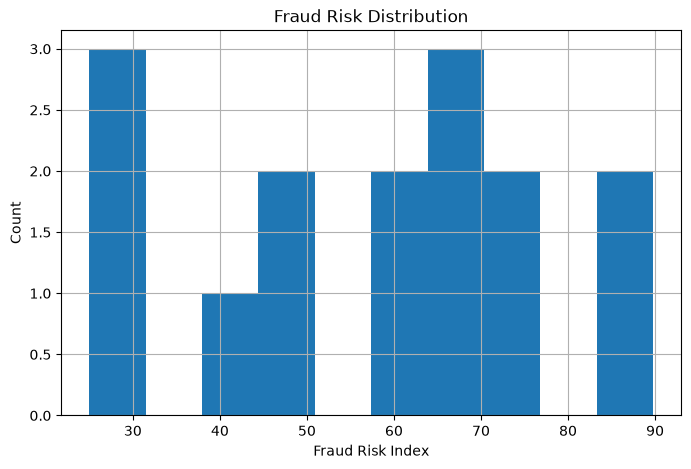

In [14]:
plt.figure(figsize=(8, 5))

claim_features_df["fraud_risk_index"].hist(bins=10)

plt.title("Fraud Risk Distribution")

plt.xlabel("Fraud Risk Index")

plt.ylabel("Count")

plt.show()

In [15]:
claim_features_df["risk_category"].value_counts()

risk_category
High        5
Medium      5
Low         3
Critical    2
Name: count, dtype: int64

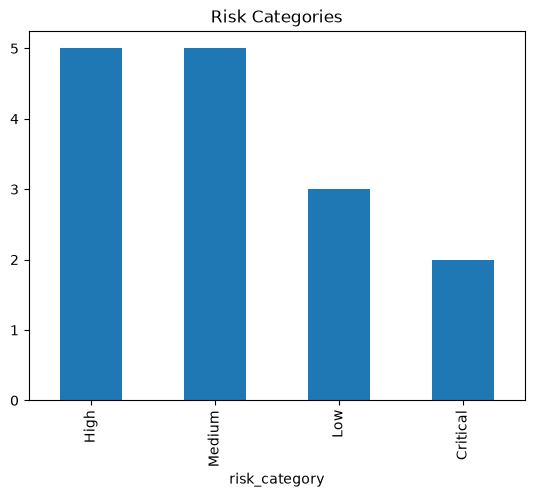

In [17]:
claim_features_df["risk_category"].value_counts().plot(kind="bar")

plt.title("Risk Categories")

plt.show()

In [18]:
investigation_queue = high_risk_claims[
    ["claim_id", "fraud_risk_index", "risk_category"]
]

In [19]:
investigation_queue.head(20)

,claim_id,fraud_risk_index,risk_category
6,CLM007,89.76,Critical
8,CLM009,84.71,Critical
0,CLM001,75.89,High
7,CLM008,74.33,High
13,CLM014,65.00,High
2,CLM003,64.40,High
12,CLM013,64.36,High
1,CLM002,57.44,Medium
3,CLM004,57.44,Medium
9,CLM010,50.00,Medium


In [20]:
def explain_fraud_score(claim_id):

    row = claim_features_df[claim_features_df["claim_id"] == claim_id].iloc[0]

    verification_risk = (1 - row["verification_score"]) * 50

    template_risk = min(row["template_matches"] * 15, 25)

    ring_risk = min(row["ring_matches"] * 10, 25)

    print(f"Claim ID: {claim_id}")

    print()

    print(f"Verification Risk: {verification_risk:.2f}")

    print(f"Template Risk: {template_risk:.2f}")

    print(f"Ring Risk: {ring_risk:.2f}")

    print()

    print(f"Final Fraud Index: {row['fraud_risk_index']}")

In [21]:
explain_fraud_score("CLM014")

Claim ID: CLM014

Verification Risk: 50.00
Template Risk: 15.00
Ring Risk: 0.00

Final Fraud Index: 65.0


In [22]:
claim_features_df[
    ["verification_score", "template_matches", "ring_matches", "fraud_risk_index"]
].corr()

,verification_score,template_matches,ring_matches,fraud_risk_index
verification_score,1.000000,0.691298,-0.209970,-0.803790
template_matches,0.691298,1.000000,0.189066,-0.285630
ring_matches,-0.209970,0.189066,1.000000,0.722554
fraud_risk_index,-0.803790,-0.285630,0.722554,1.000000


In [23]:
final_risk_df = pd.merge(claims_df, claim_features_df, on="claim_id")

In [24]:
final_risk_df.head()

,claim_id,claimant_name,vehicle_vin,mechanic_shop,clinic_name,lawyer,claimant_statement,police_report,adjuster_notes,medical_bill,fraud_label,verification_score,template_matches,ring_matches,fraud_risk_index,risk_category
0,CLM001,Wendy Holland,FqH15433919443,Rapid Auto Repair,Care First Clinic,Smith & Associates,A vehicle rear-ended me while I was waiting at...,Witnesses confirmed another driver caused the ...,Section international though many movement.,5072,0,0.182147,1,2,75.89,High
1,CLM002,Douglas Lara,acF49501195178,Rapid Auto Repair,Wellness Recovery Center,Anderson Legal,The vehicle changed lanes unexpectedly and hit...,Police observed damage consistent with reporte...,Budget Mrs part spend middle threat smile incr...,1541,0,0.351212,1,1,57.44,Medium
2,CLM003,Chloe Murphy,xeQ24677572737,Rapid Auto Repair,Care First Clinic,Justice Partners,I was stopped at a red light when another vehi...,Accident report indicates claimant followed tr...,Similar never box line.,20226,1,0.111990,0,2,64.40,High
3,CLM004,Jodi Reynolds MD,sPL40843321198,Rapid Auto Repair,Wellness Recovery Center,Justice Partners,The vehicle changed lanes unexpectedly and hit...,Police observed damage consistent with reporte...,Section season nor political bank.,7723,0,0.351212,1,1,57.44,Medium
4,CLM005,Elizabeth Patel,mmr35740163797,Prime Vehicle Repair,Wellness Recovery Center,Smith & Associates,I was driving through an intersection when ano...,Witnesses confirmed another driver caused the ...,Kind compare across audience society.,23376,0,1.000000,3,0,25.00,Low


In [25]:
critical_claims = final_risk_df[final_risk_df["risk_category"] == "Critical"]

In [26]:
critical_claims[["claim_id", "fraud_risk_index", "risk_category"]]

,claim_id,fraud_risk_index,risk_category
6,CLM007,89.76,Critical
8,CLM009,84.71,Critical


In [27]:
claim_features_df.to_csv("../data/fraud_risk_scores.csv", index=False)

In [28]:
investigation_queue.to_csv("../data/fraud_investigation_queue.csv", index=False)

In [29]:
final_risk_df.to_csv("../data/final_claim_risk_dataset.csv", index=False)